In [1]:
!python -V

Python 3.10.20


In [2]:
import pandas as pd

import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
!pip list

Package                            Version
---------------------------------- ------------
aiohappyeyeballs                   2.6.1
aiohttp                            3.13.5
aiosignal                          1.4.0
alembic                            1.18.4
annotated-doc                      0.0.4
annotated-types                    0.7.0
anyio                              4.12.1
argon2-cffi                        25.1.0
argon2-cffi-bindings               25.1.0
arrow                              1.4.0
asttokens                          3.0.1
async-lru                          2.0.5
async-timeout                      5.0.1
attrs                              26.1.0
babel                              2.17.0
beautifulsoup4                     4.14.3
bleach                             6.3.0
blinker                            1.9.0
boto3                              1.43.2
botocore                           1.43.2
Bottleneck                         1.4.2
brotlicffi                         1.2

In [6]:

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
import mlflow

In [7]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/home/omar/Documents/sololearn/MLOPS/MLOPSZoomCamp/02-experiment-tracking/mlruns/1', creation_time=1777740957951, experiment_id='1', last_update_time=1777740957951, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [8]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

In [9]:
df_train = read_dataframe('../09-data/green_tripdata_2026-01.parquet')
df_val = read_dataframe('../09-data/green_tripdata_2026-02.parquet')

In [10]:
len(df_train), len(df_val)

(38088, 35319)

In [11]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [12]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [13]:
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [14]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

#### Linear regresion

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.108767894936662

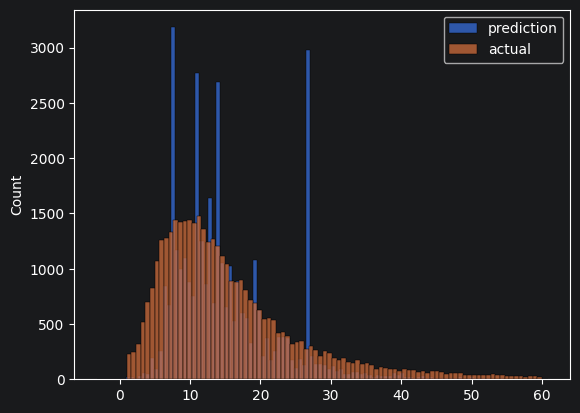

In [16]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend()

In [17]:
!mkdir models

mkdir: cannot create directory ‘models’: File exists


In [27]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

#### Lasso Regresion

In [20]:
ls = Lasso(0.01)
ls.fit(X_train, y_train)

y_pred = ls.predict(X_val)
root_mean_squared_error(y_val, y_pred)

9.105442824328877

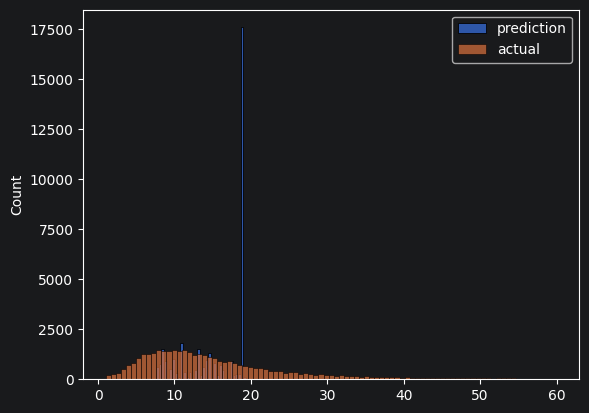

In [21]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend()

#### Starting registering runs with mlflow

In [19]:
with mlflow.start_run():
    alpha = 1

    mlflow.set_tag("developer","Omar Aliaga")
    mlflow.log_param("train-data-path","../09-data/green_tripdata_2026-01.parquet")
    mlflow.log_param("valid-data-path","../09-data/green_tripdata_2026-02.parquet")
    mlflow.log_param("alpha", alpha)

    ls = Lasso(alpha)
    ls.fit(X_train, y_train)
    y_pred = ls.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")


#### XG Bost tunning

In [21]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [22]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [23]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round = 1000,
            evals=[(valid,"validation")],
            early_stopping_rounds=50,
        )

        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[0]	validation-rmse:9.87118                           
[1]	validation-rmse:9.42141                           
[2]	validation-rmse:9.01979                           
[3]	validation-rmse:8.66197                           
[4]	validation-rmse:8.34435                           
[5]	validation-rmse:8.06331                           
[6]	validation-rmse:7.81538                           
[7]	validation-rmse:7.59733                           
[8]	validation-rmse:7.40580                           
[9]	validation-rmse:7.23827                           
[10]	validation-rmse:7.09198                          
[11]	validation-rmse:6.96411                          
[12]	validation-rmse:6.85295                          
[13]	validation-rmse:6.75633                          
[14]	validation-rmse:6.67202                          
[15]	validation-rmse:6.59904                          
[16]	validation-rmse:6.53647                          
[17]	validation-rmse:6.48199                          
[18]	valid

#### After selecting the best model

In [24]:
best_params = {
    'learning_rate' : 0.17861275283556766,
    'max_depth': 4,
    'min_child_weight': 1.3343088620760009,
    'objective': 'reg:squarederror',
    'reg_alpha': 0.06606810833324978,
    'reg_lambda': 0.019159621301293315,
    'seed': 42 ,
}

mlflow.xgboost.autolog()

booster = xgb.train(
    params=best_params,
    dtrain=train,
    num_boost_round = 1000,
    evals=[(valid,"validation")],
    early_stopping_rounds=50,
)

2026/05/07 10:38:57 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '45f742fdd09541baa52dc863f4ed6786', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:9.28376
[1]	validation-rmse:8.46695
[2]	validation-rmse:7.85619
[3]	validation-rmse:7.41061
[4]	validation-rmse:7.08452
[5]	validation-rmse:6.85285
[6]	validation-rmse:6.68383
[7]	validation-rmse:6.56644
[8]	validation-rmse:6.48349
[9]	validation-rmse:6.42148
[10]	validation-rmse:6.37849
[11]	validation-rmse:6.34758
[12]	validation-rmse:6.32007
[13]	validation-rmse:6.30286
[14]	validation-rmse:6.28743
[15]	validation-rmse:6.27736
[16]	validation-rmse:6.26941
[17]	validation-rmse:6.26214
[18]	validation-rmse:6.25791
[19]	validation-rmse:6.25296
[20]	validation-rmse:6.25140
[21]	validation-rmse:6.24876
[22]	validation-rmse:6.24467
[23]	validation-rmse:6.24332
[24]	validation-rmse:6.24161
[25]	validation-rmse:6.23736
[26]	validation-rmse:6.23402
[27]	validation-rmse:6.23234
[28]	validation-rmse:6.23112
[29]	validation-rmse:6.23088
[30]	validation-rmse:6.22901
[31]	validation-rmse:6.22787
[32]	validation-rmse:6.22615
[33]	validation-rmse:6.22531
[34]	validation-rmse:6.2

2026/05/07 10:39:09 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/05/07 10:39:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [26]:
mlflow.xgboost.autolog(disable=True)

In [31]:
with mlflow.start_run():
    best_params = {
    'learning_rate' : 0.17861275283556766,
    'max_depth': 4,
    'min_child_weight': 1.3343088620760009,
    'objective': 'reg:squarederror',
    'reg_alpha': 0.06606810833324978,
    'reg_lambda': 0.019159621301293315,
    'seed': 42 ,
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round = 1000,
        evals=[(valid,"validation")],
        early_stopping_rounds=50,
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="model_xgboost_mflow")

[0]	validation-rmse:9.28376
[1]	validation-rmse:8.46695
[2]	validation-rmse:7.85619
[3]	validation-rmse:7.41061
[4]	validation-rmse:7.08452
[5]	validation-rmse:6.85285
[6]	validation-rmse:6.68383
[7]	validation-rmse:6.56644
[8]	validation-rmse:6.48349
[9]	validation-rmse:6.42148
[10]	validation-rmse:6.37849
[11]	validation-rmse:6.34758
[12]	validation-rmse:6.32007
[13]	validation-rmse:6.30286
[14]	validation-rmse:6.28743
[15]	validation-rmse:6.27736
[16]	validation-rmse:6.26941
[17]	validation-rmse:6.26214
[18]	validation-rmse:6.25791
[19]	validation-rmse:6.25296
[20]	validation-rmse:6.25140
[21]	validation-rmse:6.24876
[22]	validation-rmse:6.24467
[23]	validation-rmse:6.24332
[24]	validation-rmse:6.24161
[25]	validation-rmse:6.23736
[26]	validation-rmse:6.23402
[27]	validation-rmse:6.23234
[28]	validation-rmse:6.23112
[29]	validation-rmse:6.23088
[30]	validation-rmse:6.22901
[31]	validation-rmse:6.22787
[32]	validation-rmse:6.22615
[33]	validation-rmse:6.22531
[34]	validation-rmse:6.2

2026/05/07 11:18:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


#### importing model

In [32]:
import mlflow.xgboost

model = mlflow.xgboost.load_model(
    "runs:/b9a05df376584972829c468dfd3e6994/model_xgboost_mflow"
)

#### Logging models in MLflow

two options:
- log model as an artifact. (you need create a binary file in local"
mlflow.log_artifact("mymodel", artifact_path="models/")
- Log model using the method log_model
mlflow.<framework>.log_model(model, artifact_path="models/")